In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
import joblib

# necessary imports (change as needed)

In [24]:
df = pd.read_csv("dataset.csv")
print(df.shape)
df.head()

(114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [25]:
df_clean = df.drop(['Unnamed: 0', 'explicit', 'album_name', 'popularity',
                    'mode', 'key', 'liveness', 'time_signature', 'duration_ms'], axis=1)
df_clean = df_clean.dropna(subset=['artists', 'track_name']).reset_index(drop=True)
df_clean.rename(columns={'artists': 'Artists',
                         'track_name': 'Song',
                         'track_genre': 'Genre',
                         'tempo': 'Tempo',
                         'danceability': 'Danceability',
                         'energy': 'Energy',
                         'loudness': 'Loudness',
                         'acousticness': 'Acousticness',
                         'instrumentalness': 'Instrumentalness',
                         'speechiness': 'Speechiness',
                         'valence': 'Valence',
                         'track_id': 'ID'}, inplace=True)
print(df_clean.shape)
print(df_clean.columns.tolist())
print(df_clean.isnull().sum())

(113999, 12)
['ID', 'Artists', 'Song', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', 'Tempo', 'Genre']
ID                  0
Artists             0
Song                0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Valence             0
Tempo               0
Genre               0
dtype: int64


In [26]:
# audio features
features = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', 'Tempo']
df_clean[features].describe()
# NOTE: tempo and loudness needs to be normalized

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,Tempo
count,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,0.566801,0.641383,-8.258950,0.084652,0.314907,0.156051,0.474066,122.147695
std,0.173543,0.251530,5.029357,0.105733,0.332522,0.309556,0.259261,29.978290
min,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.456000,0.472000,-10.013000,0.035900,0.016900,0.000000,0.260000,99.218500
50%,0.580000,0.685000,-7.004000,0.048900,0.169000,0.000042,0.464000,122.017000
75%,0.695000,0.854000,-5.003000,0.084500,0.597500,0.049000,0.683000,140.071000
max,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,0.995000,243.372000


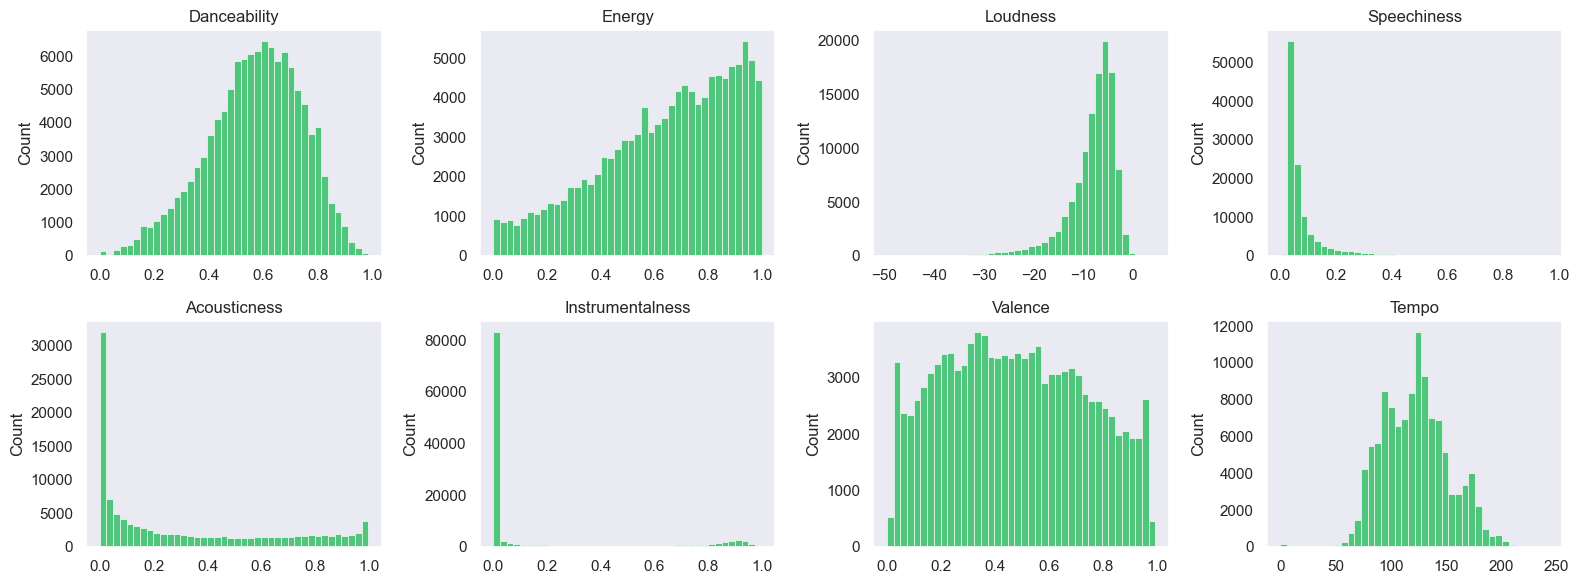

In [27]:
# visualize features
sns.set_theme(style='dark', palette='muted')
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, feat in enumerate(features):
    ax = axes[i // 4][i % 4]
    sns.histplot(df_clean[feat].dropna(), ax=ax, bins=40, color='#1db954')
    ax.set_title(feat)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [28]:
# Build the feature matrix used by KNN.
#
# The raw CSV lists each track once per genre category, so track_ids repeat
# with different `Genre` labels. Naive drop_duplicates(keep='first') throws
# away every alternate genre tag — and because one-hot genres dominate the
# 122-dim feature space, Manhattan-distance neighbors end up in whatever
# genre the retained row happened to be labeled with (e.g., Calvin Harris's
# "Summer" -> folk). Fix: aggregate genres to a multi-hot vector per ID,
# then keep one audio-feature row per track.
def clean_and_scale(df):
    genre_multihot = pd.get_dummies(df['Genre']).groupby(df['ID']).max()
    audio = (df.drop_duplicates(subset='ID', keep='first')
               .set_index('ID')[features])
    combined = audio.join(genre_multihot)
    scaled = MinMaxScaler().fit_transform(combined)
    return pd.DataFrame(scaled, index=combined.index, columns=combined.columns)

scaled_df = clean_and_scale(df_clean)

# Lookup table aligned to scaled_df for displaying song/artist/genre in results.
track_lookup = (df_clean.drop_duplicates(subset='ID', keep='first')
                         .set_index('ID')
                         .loc[scaled_df.index])

print(f"Unique tracks: {len(scaled_df):,} (from {len(df_clean):,} rows)")
scaled_df.head()

Unique tracks: 89,740 (from 113,999 rows)


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,Tempo,acoustic,afrobeat,...,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
ID,,,,,,,,,,,,,,,,,,,,,
5SuOikwiRyPMVoIQDJUgSV,0.686294,0.4610,0.791392,0.148187,0.032329,0.000001,0.718593,0.361245,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4qPNDBW1i3p13qLCt0Ki3A,0.426396,0.1660,0.597377,0.079067,0.927711,0.000006,0.268342,0.318397,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1iJBSr7s7jYXzM8EGcbK5b,0.444670,0.3590,0.736123,0.057720,0.210843,0.000000,0.120603,0.313643,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6lfxq3CG4xtTiEg7opyCyx,0.270051,0.0596,0.573701,0.037617,0.908635,0.000071,0.143719,0.746758,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5vjLSffimiIP26QG5WcN2K,0.627411,0.4430,0.737103,0.054508,0.470884,0.000000,0.167839,0.492863,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 113999 entries, 0 to 113998
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                113999 non-null  str    
 1   Artists           113999 non-null  str    
 2   Song              113999 non-null  str    
 3   Danceability      113999 non-null  float64
 4   Energy            113999 non-null  float64
 5   Loudness          113999 non-null  float64
 6   Speechiness       113999 non-null  float64
 7   Acousticness      113999 non-null  float64
 8   Instrumentalness  113999 non-null  float64
 9   Valence           113999 non-null  float64
 10  Tempo             113999 non-null  float64
 11  Genre             113999 non-null  str    
dtypes: float64(8), str(4)
memory usage: 10.4 MB


In [30]:
df_clean['Genre'].value_counts()

Genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
k-pop           999
Name: count, Length: 114, dtype: int64

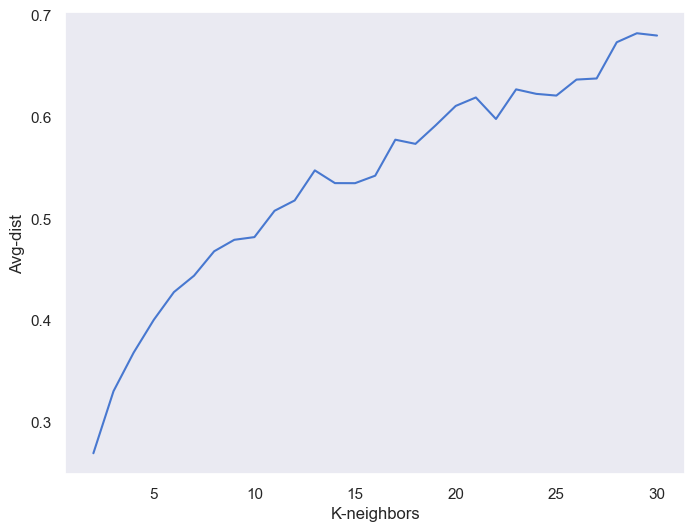

In [31]:
# build the model
feature_matrix = scaled_df.values
k_neighbors = range(2, 31)
avg_dists = []

for k in k_neighbors:
    curr_knn = NearestNeighbors(n_neighbors=k, metric='manhattan', algorithm='brute')
    curr_knn.fit(feature_matrix)

    sample_indices = np.random.choice(len(feature_matrix), 1000, replace=False)
    distances, _ = curr_knn.kneighbors(feature_matrix[sample_indices])
    avg_dists.append(distances[:, -1].mean())

plt.figure(figsize=(8,6))
plt.plot(list(k_neighbors), avg_dists)
plt.xlabel('K-neighbors')
plt.ylabel('Avg-dist')
plt.show()

In [32]:
kneedle = KneeLocator(
    list(k_neighbors),
    avg_dists,
    curve='concave',
    direction='increasing'
)

optimal_k = kneedle.knee
print(f"Optimal k neighbors: {optimal_k}")

Optimal k neighbors: 8


In [33]:
knn = NearestNeighbors(n_neighbors=optimal_k, metric='manhattan', algorithm='brute')
knn.fit(feature_matrix)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(8)
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [34]:
def recommend(Song, Artist, n=10):
    matches = track_lookup[(track_lookup['Song'].str.lower() == Song.lower()) &
                           (track_lookup['Artists'].str.lower() == Artist.lower())]
    if matches.empty:
        return f"Track {Song} by {Artist} not found"

    track_id = matches.index[0]
    pos = scaled_df.index.get_loc(track_id)
    track_vector = feature_matrix[pos].reshape(1, -1)

    distances, indices = knn.kneighbors(track_vector, n_neighbors=n + 1)
    neighbor_positions = indices[0][1:]
    neighbor_distances = distances[0][1:]
    neighbor_ids = scaled_df.index[neighbor_positions]

    results = track_lookup.loc[
        neighbor_ids,
        ['Song', 'Artists', 'Danceability', 'Energy', 'Valence', 'Genre']
    ].copy()
    results['similarity'] = (1 - neighbor_distances).round(3)
    results = results.reset_index(drop=True)
    results.index += 1
    return results

recommend('summer', 'calvin harris')

,Song,Artists,Danceability,Energy,Valence,Genre,similarity
1,Feel So Close - Radio Edit,Calvin Harris,0.707,0.924,0.919,electro,0.594
2,Over Now (with The Weeknd),Calvin Harris;The Weeknd,0.612,0.884,0.679,electro,0.593
3,One Kiss,Calvin Harris;Dua Lipa,0.753,0.852,0.586,electro,0.518
4,My Way,Calvin Harris,0.818,0.913,0.536,electro,0.369
5,Promises (with Sam Smith),Calvin Harris;Sam Smith;Jessie Reyez,0.781,0.768,0.486,electro,0.369
6,Outside (feat. Ellie Goulding),Calvin Harris;Ellie Goulding,0.646,0.823,0.418,electro,0.363
7,Blame (feat. John Newman),Calvin Harris;John Newman,0.414,0.857,0.348,electro,0.340
8,How Deep is Your Love (feat. Disciples),Calvin Harris;Disciples,0.738,0.868,0.336,electro,0.321
9,Potion (with Dua Lipa & Young Thug),Calvin Harris;Dua Lipa;Young Thug,0.824,0.697,0.757,electro,0.288
10,Potion (with Dua Lipa & Young Thug),Calvin Harris;Dua Lipa;Young Thug,0.824,0.697,0.757,electro,0.288


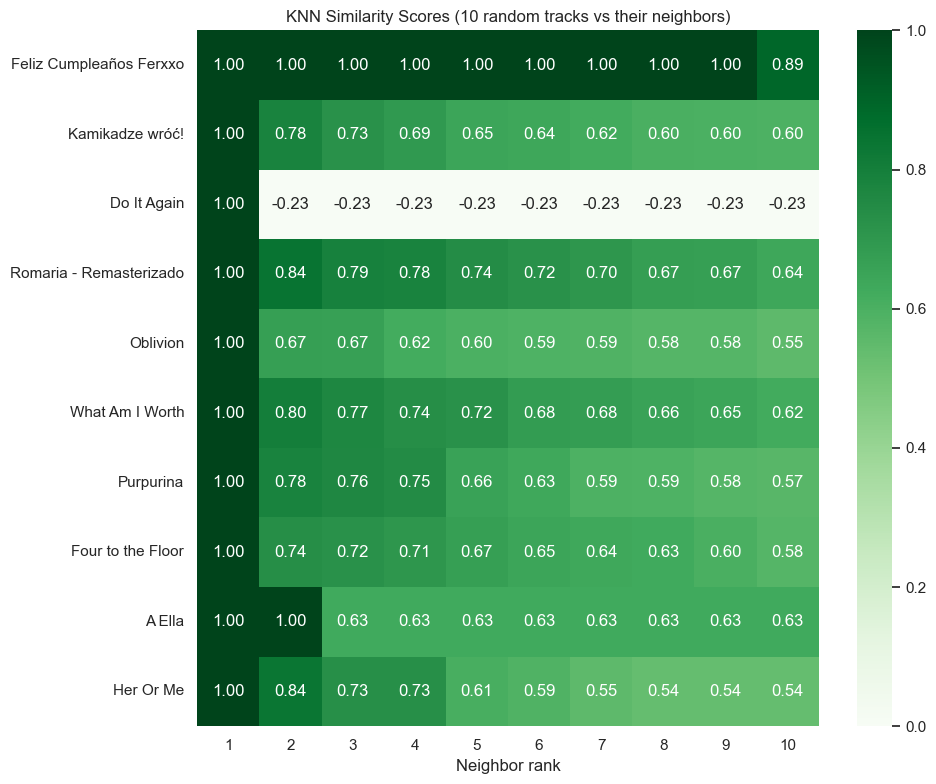

In [35]:
sample_tracks = scaled_df.sample(10, random_state=42)
sample_matrix = sample_tracks.values

distances, _ = knn.kneighbors(sample_matrix, n_neighbors=10)
sim_matrix = 1 - distances  # convert to similarity

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    xticklabels=range(1, 11),
    yticklabels=track_lookup.loc[sample_tracks.index, 'Song'].str[:25].values,
    cmap='Greens',
    annot=True,
    fmt='.2f',
    vmin=0,
    vmax=1
)
plt.title('KNN Similarity Scores (10 random tracks vs their neighbors)')
plt.xlabel('Neighbor rank')
plt.tight_layout()
plt.show()

In [36]:
def precision_at_k(track_name, artists, k=5):
    matches = track_lookup[(track_lookup['Song'].str.lower() == track_name.lower()) &
                           (track_lookup['Artists'].str.lower() == artists.lower())]
    if matches.empty:
        return f"Track {track_name} by {artists} not found"

    seed_genre = matches.iloc[0]['Genre']
    recs = recommend(track_name, artists, n=k)
    if isinstance(recs, str):
        return recs

    matching = (recs['Genre'] == seed_genre).sum()
    return f'Precision@{k}: {matching}/{k} recommendations share genre "{seed_genre}"'

print(precision_at_k('Blinding Lights', 'The Weeknd', k=5))
print(precision_at_k('Blinding Lights', 'The Weeknd', k=10))
print(precision_at_k('summer', 'calvin harris', k=5))

Precision@5: 5/5 recommendations share genre "pop"
Precision@10: 10/10 recommendations share genre "pop"
Precision@5: 5/5 recommendations share genre "electro"


In [37]:
track_lookup[track_lookup['Song'].str.lower() == 'summer'][
    ['Song', 'Artists', 'Genre']
]

,Song,Artists,Genre
ID,,,
0LqCvXVNvcnkq78sCQsoO0,summer,keshi,chill
6YUTL4dYpB9xZO5qExPf05,Summer,Calvin Harris,electro
28iXG2opEt5YUr1yZlcOfe,Summer,Steve Kroeger;Life of Kai,electronic
5cY5o3LJZpC7K7p4pyAn8n,Summer,Beatsteaks,german
1Hk0QRlUFCHYG6zIvUh0Xd,Summer,Marshmello,progressive-house
